<a href="https://colab.research.google.com/github/JuanLema14/laboratorios-modelos-2/blob/main/lab3_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 3 - Parte 2. Comparación de metodos basados en árboles

In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources
replicating Labs resources


In [2]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L03.02", varname="student", session_id="udea.vir.20262.g1");

logging in as andres.lema1@udea.edu.co... please wait
you are registered in the following sessions of this course

     ['udea.vir.20261', 'udea.vir.20262.g1']

and you have explicitly requested session 'udea.vir.20262.g1'.
your grades will be reported in that session

-------------
using course session introml::udea.vir.20262.g1
success!! you are logged in
-------------


In [3]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab3 import *
_ = part_2()

A continuación se leen los datos de un problema de clasificación. El problema corresponde a la clasifiación de dígitos escritos a mano, el cual fue abordado en el laboratorio anterior. Usaremos únicamente 4 de las 10 clases disponibles, usando solo los números pares. Nuevamente, los datos fueron preprocesados con PCA para reducir el número de características.

In [4]:
digits = load_digits(n_class=10)
#--------- preprocesamiento usando solo los pares--------------------
pca = PCA(0.99, whiten=True)
data = pca.fit_transform(digits.data[np.isin(digits.target, [2,4,6,8,10])])
#---------- Datos a usar ----------------------
x = data
y =  digits.target[np.isin(digits.target, [2,4,6,8,10])]

## Ejercicio 1 Experimentos con Arboles de decisión

Debe consultar todo lo relacionado con la creación, entrenamiento y uso en predicción del modelo conocido como árbol de decisión usando la librería scikit-learn. En este enlace, se puede leer la documentación http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html.

En el notebook, ya se encuentra cargada la libreria:

```python
from sklearn.tree import DecisionTreeClassifier
```

Las siguientes preguntas abiertas, buscan verificar que se está haciendo un contraste con la librería y la teoría, por lo tanto procura incluir conceptos asociados y **NO** solo enfocarse en las descripciones de la documentación.

In [ ]:
#@title Pregunta Abierta
#@markdown  ¿Qué efecto tienen los parámetros min_samples_split y max_depth definidos en la librería?
respuesta = "" #@param {type:"string"}

In [ ]:
#@title Pregunta Abierta
#@markdown ¿Cuál es la diferencia entre min_samples_leaf y min_samples_split? Y explique la diferencia fundamental de estos dos con respecto a min_impurity_decrease.
respuesta = "" #@param {type:"string"}

En la siguiente celda se define una simulación para entrenar y validar un modelo usando los datos previamente cargados. Complete el código para usar como modelo de predicción un arbol de decisión.


<b>Note</b> que existe una clase para modelos de clasificación y otra para modelos de regresión:
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

Vamos a tener en cuenta lo siguiente:
1. dentro del código, ya se encuentra sugerida la metodologia de validación
2. la función va aceptar un parametro booleano, dependiendo del valor de esta parametro, se ejecutara normalización de los datos.
3. **hacer uso explicito del nombre del parametro que se va usar**, por ejemplo, si se requeire asignar el parametro `max_features`  debemos llamar la libreria de esta manera: `DecisionTreeClassifier(max_features = 'auto')`
4. Vamos a configurar el arbol con la medida de impureza Gini

In [5]:
#ejercicio de código
def experimentar_dt( X, Y, depths,normalize):
    """función que realiza experimentos con árboles de decisión
    X: matriz con las características
    Y: matriz de numpy con etiquetas
    depths: list[int] lista con la profundidad de arboles a experimentar
    normalize bool: indica si se aplica normalización a los datos
    retorna: dataframe con:
        - profunidad de los árboles
        - eficiencia de entrenamiento
        - desviación estandar de la eficiencia de entrenamiento
        - eficiencia de prueba
        - desviación estandar de la eficiencia de prueba
    """
    folds = 4
    skf = StratifiedKFold(n_splits=folds)
    resultados = pd.DataFrame()
    idx = 0
    for depth in depths:
        ## para almacenar los errores intermedios
        EficienciaTrain = []
        EficienciaVal = []
        for train, test in skf.split(X, Y):
            Xtrain = X[train,:]
            Ytrain = Y[train]
            Xtest = X[test,:]
            Ytest = Y[test]
            #Normalizamos los datos
            # si la bandera esta en True
            if normalize:
                scaler = StandardScaler()
                scaler.fit(Xtrain)
                Xtrain= scaler.transform(Xtrain)
                Xtest = scaler.transform(Xtest)
            #Haga el llamado a la función para crear y entrenar el modelo usando los datos de entrenamiento
            #Ajuste la semilla en 0 para garantizar la reproducibilidad de los resultados
            modelo = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=0)
            modelo.fit(Xtrain, Ytrain)
            #predecir muestras de entrenamiento
            Ytrain_pred = modelo.predict(Xtrain)
            #predecir muestras de pruebas
            Yest = modelo.predict(Xtest)
            #Evaluamos las predicciones del modelo con los datos de test
            EficienciaTrain.append(np.mean(Ytrain_pred.ravel() == Ytrain.ravel()))
            EficienciaVal.append(np.mean(Yest.ravel() == Ytest.ravel()))

        resultados.loc[idx,'profunidad del arbol'] = depth
        resultados.loc[idx,'eficiencia de entrenamiento'] = np.mean(EficienciaTrain)
        resultados.loc[idx,'desviacion estandar entrenamiento'] = np.std(EficienciaTrain)
        resultados.loc[idx,'eficiencia de prueba'] = np.mean(EficienciaVal)
        resultados.loc[idx,'desviacion estandar prueba'] = np.std(EficienciaVal)
        idx= idx +1

    return (resultados)

**Registra tu solución en línea**

In [6]:
student.submit_task(namespace=globals(), task_id='T1');

In [8]:
# Realiza los experimentos sin normalizacion
depths = [5,10,20,30,50]
resultados_dt_no_norm = experimentar_dt(X = x , Y = y, depths = depths, normalize=False)
resultados_dt_no_norm

,profunidad del arbol,eficiencia de entrenamiento,desviacion estandar entrenamiento,eficiencia de prueba,desviacion estandar prueba
0,5.0,0.994859,0.002763,0.911658,0.018697
1,10.0,1.000000,0.000000,0.927060,0.034874
2,20.0,1.000000,0.000000,0.927060,0.034874
3,30.0,1.000000,0.000000,0.927060,0.034874
4,50.0,1.000000,0.000000,0.927060,0.034874


In [ ]:
# Realiza los experimentos con normalizacion
depths = [5,10,20,30,50]
resultados_dt_norm = experimentar_dt(X = x , Y = y, depths = , normalize=)
resultados_dt_norm

In [ ]:
#@title Pregunta Abierta
#@markdown  ¿Tiene algún efecto la normalización o estándarización de las variables en el desempeño del modelo de árboles de decisión? Justifique.
respuesta = "" #@param {type:"string"}

## Ejercicio 2 Experimentos con Random Forest

En la siguiente celda se define una simulación para entrenar y validar un modelo usando los datos previamente cargados. Complete el código para usar como modelo de predicción un Random Forest. Debe consultar todo lo relacionado con la creación, entrenamiento y uso en predicción de este modelo usando la librería scikit-learn. Consultar aquí: http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html.

En el notebook, ya se encuentra cargada la clase:

```python
from sklearn.ensemble import RandomForestClassifier

```

<b>Note</b> que al igual que en el caso anterior, existe una clase para modelos de clasificación y otra para modelos de regresión: http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

**Recorde que para instancias un objeto de la clase no se usan parámetros posicionales; todo los parámetros deben ser llamados por su nombre.

Para nuestros experimentos vamos a configurar el RF para que el mínimo de muestras a considerar en un nodo hoja sea 3.

In [9]:
#ejercicio de código
def experimentar_rf(X, Y, num_trees,numero_de_variables):
    """función que realiza experimentos con el modelo random forest
    X: matriz con las caractersiticas
    Y: matriz de numpy con etiquetas
    num_trees: list[int]: lista con el número de arboles usado para el RF
    numero_de_variables list[int]: lista con variables para la selección del mejor umbral en cada nodo
    retorna: dataframe con:
        -  numero de arboles usados
        -  variables para la selección del mejor umbral
        - eficiencia de entrenamiento
        - desviación de estandar de la eficiencia de entrenamiento
        - eficiencia de prueba
        - desviación estandar de la eficiencia de prueba
    """
    folds = 4
    skf = StratifiedKFold(n_splits=folds)
    resultados = pd.DataFrame()
    idx = 0
    for trees in num_trees:
        for num_variables in numero_de_variables:
            ## para almacenar los errores intermedios
            EficienciaTrain = []
            EficienciaVal = []
            for train, test in skf.split(X, Y):
                Xtrain = X[train,:]
                Ytrain = Y[train]
                Xtest = X[test,:]
                Ytest = Y[test]
                #Haga el llamado a la función para crear y entrenar el modelo usando los datos de entrenamiento
                #Ajuste la semilla en 0 para garantizar la reproducibilidad de los resultados
                modelo = RandomForestClassifier(n_estimators=trees, max_features=num_variables, min_samples_leaf=3, random_state=0)
                modelo.fit(Xtrain, Ytrain)
                #predecir muestras de entrenamiento
                Ytrain_pred = modelo.predict(Xtrain)
                #predecir muestras de pruebas
                Yest = modelo.predict(Xtest)
                #Evaluamos las predicciones del modelo con los datos de test
                EficienciaTrain.append(np.mean(Ytrain_pred.ravel() == Ytrain.ravel()))
                EficienciaVal.append(np.mean(Yest.ravel() == Ytest.ravel()))

            resultados.loc[idx,'número de arboles'] = trees
            resultados.loc[idx,'variables para la selección del mejor umbral'] = num_variables
            resultados.loc[idx,'eficiencia de entrenamiento'] = np.mean(EficienciaTrain)
            resultados.loc[idx,'desviacion estandar entrenamiento'] = np.std(EficienciaTrain)
            resultados.loc[idx,'eficiencia de prueba'] = np.mean(EficienciaVal)
            resultados.loc[idx,'desviacion estandar prueba'] = np.std(EficienciaVal)
            idx= idx +1
        print(f"termina para {trees} arboles")

    return (resultados)

**Registra tu solución en línea**

In [10]:
student.submit_task(namespace=globals(), task_id='T2');

Una vez completado el código realice los experimentos necesarios para llenar la siguiente tabla:

In [12]:
arboles = [5,10,20,50,100, 150]
variables_seleccion = [5,20,40]
resultados_rf = experimentar_rf(X=x, Y=y, num_trees = arboles, numero_de_variables = variables_seleccion)
resultados_rf

termina para 5 arboles
termina para 10 arboles
termina para 20 arboles
termina para 50 arboles
termina para 100 arboles
termina para 150 arboles


,número de arboles,variables para la selección del mejor umbral,eficiencia de entrenamiento,desviacion estandar entrenamiento,eficiencia de prueba,desviacion estandar prueba
0,5.0,5.0,0.989714,0.003101,0.865412,0.031730
1,5.0,20.0,0.991118,0.002763,0.939717,0.016438
2,5.0,40.0,0.984575,0.005813,0.934114,0.024163
3,10.0,5.0,0.996728,0.001549,0.929893,0.013928
4,10.0,20.0,0.993922,0.001553,0.950937,0.017388
5,10.0,40.0,0.983171,0.007114,0.936900,0.023918
6,20.0,5.0,0.999533,0.000809,0.949517,0.006818
7,20.0,20.0,0.996259,0.002291,0.950929,0.019558
8,20.0,40.0,0.984105,0.004672,0.938304,0.023454
9,50.0,5.0,1.000000,0.000000,0.962141,0.009163


Vamos a comparar los resultados del RF con los del DT.

In [13]:
print("diferencia promedio entre entrenamiento y prueba del DT",
      resultados_dt_norm['eficiencia de entrenamiento'].mean()-resultados_dt_norm['eficiencia de prueba'].mean())

print("diferencia promedio entre entrenamiento y prueba del RF",
      resultados_rf['eficiencia de entrenamiento'].mean()-resultados_rf['eficiencia de prueba'].mean())

NameError: name 'resultados_dt_norm' is not defined

## Ejercicio 3 Experimentos con Gradient Boosted Trees

En la siguiente celda se define una simulación para entrenar y validar un modelo usando los datos previamente cargados. Complete el código para usar como modelo de predicción un Gradient boosted Tree. Debe consultar todo lo relacionado con la creación, el entrenamiento y el uso en predicción de este modelo usando la librería scikit-learn. Consultar aquí: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

En el notebook, ya se encuentra cargada la libreria:

```python
from sklearn.ensemble import GradientBoostingClassifier

```

Debemos configurar los árboles con un mínimo de tres (3) muestras para considerar la división de un nodo.

<b>Note</b> que al igual que en el caso anterior, existe una clase para modelos de clasificación y otra para modelos de regresión: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html#sklearn.ensemble.GradientBoostingRegressor

In [14]:
#ejercicio de código
def experimentar_gbt(num_trees, X, Y):
    """funcion que realiza experimentos de arboles de decision
    num_trees: list[int] lista con el número de arboles usado para el RF
    X: matriz con las caractersiticas
    Y: matriz de numpy con etiquetas
    retorna: dataframe con:
        - numero de arboles usados
        - eficiencia de entrenamiento
        - desviacion de estandar eficiencia de entrenamiento
        - eficiencia de prueba
        - desviacion estandar eficiencia de prueba
    """
    folds = 4
    skf = StratifiedKFold(n_splits=folds)
    resultados = pd.DataFrame()
    idx = 0
    for trees in num_trees:
        ## para almacenar los errores intermedios
        EficienciaTrain = []
        EficienciaVal = []
        for train, test in skf.split(X, Y):
            Xtrain = X[train,:]
            Ytrain = Y[train]
            Xtest = X[test,:]
            Ytest = Y[test]
            #Haga el llamado a la función para crear y entrenar el modelo usando los datos de entrenamiento
            #Ajuste la semilla en 0 para garantizar la reproducibilidad de los resultados
            modelo = GradientBoostingClassifier(n_estimators=trees, min_samples_split=3, random_state=0)
            modelo.fit(Xtrain, Ytrain)
            #predecir muestras de entrenamiento
            Ytrain_pred = modelo.predict(Xtrain)
            #predecir muestras de pruebas
            Yest = modelo.predict(Xtest)
            #Evaluamos las predicciones del modelo con los datos de test
            EficienciaTrain.append(np.mean(Ytrain_pred.ravel() == Ytrain.ravel()))
            EficienciaVal.append(np.mean(Yest.ravel() == Ytest.ravel()))

        resultados.loc[idx,'número de arboles'] = trees
        resultados.loc[idx,'eficiencia de entrenamiento'] = np.mean(EficienciaTrain)
        resultados.loc[idx,'desviacion estandar entrenamiento'] = np.std(EficienciaTrain)
        resultados.loc[idx,'eficiencia de prueba'] = np.mean(EficienciaVal)
        resultados.loc[idx,'desviacion estandar prueba'] = np.std(EficienciaVal)
        idx= idx +1

    return (resultados)

**Registra tu solución en línea**

In [15]:
student.submit_task(namespace=globals(), task_id='T3');

In [18]:
# ejecuta para realizar los experimentos
arboles = [5,10,20,50,100, 150]
resultados_gbt = experimentar_gbt(arboles, x, y)
resultados_gbt

,número de arboles,eficiencia de entrenamiento,desviacion estandar entrenamiento,eficiencia de prueba,desviacion estandar prueba
0,5.0,0.991121,0.004256,0.913023,0.044535
1,10.0,0.995794,0.002427,0.925664,0.047070
2,20.0,1.000000,0.000000,0.948128,0.025804
3,50.0,1.000000,0.000000,0.953746,0.014392
4,100.0,1.000000,0.000000,0.952349,0.017843
5,150.0,1.000000,0.000000,0.952349,0.016463


Vamos a graficar la eficiencia para el RF y el GBT en función del número de arboles.

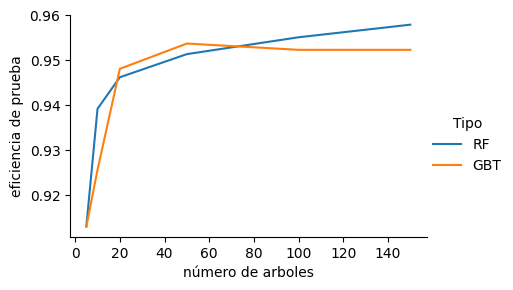

In [19]:
# se crea un df para agrupar los resultados
# y graficar las diferencias entre el GBT y el RF
import seaborn as sns
rf_res = resultados_rf.groupby("número de arboles")['eficiencia de prueba'].mean().reset_index()
rf_res['Tipo'] = 'RF'
gbt_res = resultados_gbt.groupby("número de arboles")['eficiencia de prueba'].mean().reset_index()
gbt_res['Tipo'] = 'GBT'
data_to_plot= pd.concat([rf_res, gbt_res], ignore_index=True)
sns.relplot(data=data_to_plot, x= 'número de arboles', y = 'eficiencia de prueba', hue = 'Tipo', kind='line', aspect=1.5,height=3)
plt.show()

## Ejercicio 4 Tiempo de entrenamiento del RF y GBT

En nuestro último experimento, vamos a evaluar la influencia de los parámetros del RF y del GBT en el tiempo de entrenamiento.

Para ello vamos a crear una función para medir el tiempo de entrenamiento usando la instrucción `time.process_time()`.

Vamos crear la función, para poder evaluar la influencia de:
1. número de árboles
2. cantidad de variables a analizar por nodo

En el entrenamiento del RF y del GBT.

**Notar**  
1. No vamos a dividir el conjunto de muestras ya que el objetivo es evaluar el tiempo de entrenamiento y no la eficiencias del modelo
2. No calcularemos las prediciones

In [20]:
#ejercicio de código
def time_rf_gbt_training(X, Y, num_trees, numero_de_variables, metodo):
    """función que realiza experimentos para determinar la influencia
    del número de árboles y de características por nodo en el tiempo de entrenamiento
    del RF
    X: conjunto de datos para realizar los experimentos
    Y: conjunto de etiquetas de clase
    num_trees: List[int] lista con el número de arboles a evaluar
    num_variables: List[int] lista con el número variables a evaluar
    metodo: 'rf' o 'gbt', de acuerdo a esto se verifica cual modelo a evaluar.
    retorna: dataframe con:
    - número de arboles
    - variables para la selección del mejor umbral
    - tiempo de entrenamiento (promedio)
    """
    resultados = pd.DataFrame()
    idx = 0

    for trees in num_trees:
        for variables in numero_de_variables:
            ## ejecutar 5 veces lo mismo
            ## para llegar a un tiempo más adecuado
            tiempos = []
            for i in range(5):
            ## llamar la funcion para inicar el conteo
                start = time.process_time()
                 #Ajuste la semilla en 0 para garantizar la reproducibilidad de los resultados
                if metodo == 'rf':
                    modelo = RandomForestClassifier(n_estimators=trees, max_features=variables, min_samples_leaf=3, random_state=0)
                else:
                    modelo = GradientBoostingClassifier(n_estimators=trees, max_features=variables, min_samples_split=3, random_state=0)

                modelo.fit(X, Y)
                ## obtener tiempo
                end = time.process_time()
                # append de la resta de fin y end
                tiempos.append(end - start)
            resultados.loc[idx,'numero de arboles'] = trees
            resultados.loc[idx,'variables para la seleccion del mejor umbral'] = variables
            # obtenga el promedio
            resultados.loc[idx,'tiempo de entrenamiento'] = np.mean(tiempos)
            resultados.loc[idx,'metodo'] = metodo
            idx = idx +1
    return(resultados)

**Registra tu solución en línea**

In [21]:
student.submit_task(namespace=globals(), task_id='T4');

Vamos a dejar fijo el número de variables en 20 y variar los árboles en: [5,10,15,25, 50], completa el código para ver la gráfica

In [ ]:
resultados_rf_time1 = time_rf_gbt_training(x, y, [], [], metodo = 'rf')
resultados_gbt_time1 = time_rf_gbt_training(x, y, [], [], metodo = 'gbt')

resultados_time = pd.concat([resultados_rf_time1, resultados_gbt_time1], ignore_index=True)

sns.relplot(data = resultados_time, x = 'numero de arboles', y = 'tiempo de entrenamiento', hue = 'metodo', kind = 'line')

Y por ultimo vamos a dejar fijo el número de árboles en 20 y el número de varaibles [5,10,15,20,40], completa el código para ver la gráfica

In [ ]:
resultados_rf_time1 = time_rf_gbt_training(x, y, [], [], metodo = 'rf')
resultados_gbt_time1 = time_rf_gbt_training(x, y, [], [], metodo = 'gbt')

resultados_time = pd.concat([resultados_rf_time1, resultados_gbt_time1], ignore_index=True)

sns.relplot(data = resultados_time, x = 'variables para la seleccion del mejor umbral', y = 'tiempo de entrenamiento', hue = 'metodo', kind = 'line')

In [ ]:
#@title Pregunta Abierta
#@markdown Cuál parámetro de los evaluados tiene una mayor influencia en los tiempos de entrenamiento? ¿Porqué?
respuesta = "" #@param {type:"string"}